<p class="h1">ECE 447 - Notebook 04</p>
<p class="h1">Linear Models</p>
<p class="h2">Regression: part I</p>

In this section, we cover the following concepts:

- what is regression and how is it used for prediction purposes;
- how linear regression works;
- how to determine the quality of predictions;
- what is a gradient descent method and how does it work;
- how to use `sklearn` to compute a linear regression.

# Linear Regression

It is quite common to ask ourselves some of the following questions:

- how to determine the price of a house based on the house area, location, number of rooms, etc.;
- how to predict when a product needs to be restock based on the demand, and time of year, etc.;
- how to determine height from age;
- how to forecast the price of a stock.

So, the question is: how do we build models that make accurate and useful predictions? 

## Regression

One of many approaches to solve these problems is to use a regression model.

Based on [Merriam Webster](https://www.merriam-webster.com/dictionary/regression), **regression** is defined as follows:

> "A functional relationship between two or more correlated variables that is often empirically determined from data and is used especially to predict values of one variable when given values of the others."

More generally, regression is:

>  A method to *predict countinuous* output values based on a set of observations.

## Linear regression

**Linear regression** is a model that assumes a linear relationship between  input variables ($x$ o *Features*) and a single output variable ($y$), where the output variable ($y$) can be calculated from a linear combination of the input variables ($x$).

In [1]:
# Library to manipulate matrices
import numpy as np
# Plotting library 
import matplotlib.pyplot as plt

import ipywidgets as widgets
%matplotlib inline

In [2]:
# Simple function to generate points around a line
def gen_linear_samples(n, sz=20, a=0.7, s=5, b=5):
    """
    n: Number of point to generate
    sz: generation of point from 0 to sz for the x axis
    a: lines slope
    s: spread distance
    b: intercept with y axis
    """
    X = sz * np.random.ranf(n)
    Yo = a*X + b
    Y = Yo + 2*s*np.random.ranf(X.size) - s
    return X.reshape(n,1),Y.reshape(n,1)

In [5]:
np.random.seed(10)
x,y = gen_linear_samples(25, sz=20, a=0.6, s=3, b=5)
xl = np.linspace(0, 20, 20)

out1 = widgets.Output()
out2 = widgets.Output()
out = widgets.Tab(children = [out1, out2])
out.set_title(0, 'Data')
out.set_title(1, 'Regresion')
    
with out1:
    fig1, ax = plt.subplots(figsize=(8,7))
    ax.scatter(x,y)
    ax.set_ylim([2,20])
    plt.show(fig)

with out2:
    fig, ax = plt.subplots(figsize=(8,7))
    ax.scatter(x,y)
    ax.plot(x,0.6*x+5,'r', label="y = 0.6x + 5")
    ax.plot(x,0.7*x+4,'g', label="y = 0.7x + 4")
    ax.set_ylim([2,20])
    plt.show(fig)

In [6]:
display(out)

<div class="alert alert-success">
<h2>Exercise</h2>
    
✏️ Using the above code run a few experiments with differnet parameters, and display obtained data.
</div>

# Hypothesis

A **hypothesis** or **prediction** defines a model that we want to use for prediction purposes. A hypothesis is parameterized by a set of parameters that we want to *learn* from the existing data.  

In this case, a relation between *features* ($x$) and the output can be represented as a linear equation: 

$$
f_\theta(x) = \theta_1 x + \theta_0,
$$

where $f_\theta(x)$ is called the hypothesis (predictor), and $\theta_0, \theta_1$ are the parameters (*weights*) we want to learn.

In [7]:
def predictor(x, w0, w1):
    return w1*x + w0

Using a matrix representation, we have

In [8]:
def predictor(Features, Weights):
    return Features @ Weights # dot product

# Cost function

We need to determine how well the parameters  𝜃  predict the output values.

A **cost function**, sometime also called  a **loss function**, shows how accurate  predictions of the hypothesis are with the current set of weights (parameters).

Again, let us generate random data points, and plot a regression model representing the data.

In [9]:
np.random.seed(10)
x,y = gen_linear_samples(25, sz=20, a=0.6, s=3, b=5)

out = widgets.Output()
with out:
    fig, ax = plt.subplots(figsize=(8,7))
    ax.set_ylim([2,20])
    ax.scatter(x,y)
    ax.plot(x,0.5*x + 6,'r')
    plt.show(fig)

In [10]:
display(out)

Output()

A value of **cost function** is an indicator how "close" the data points are to the line - regrestion model.
It is an indicator how good a model is: lower the value better the model.

## Types of cost functions

**Least Squared**
$J(\theta) = \frac{1}{2}\sum_{i=1}^n(y-f_\theta(x_i))^2$

**Mean Square Error (MSE)**
$J(\theta) = \frac{1}{2n}\sum_{i=1}^n(y-f_\theta(x_i))^2$,

where $n$ is the number of input data.

## Cost functions

#### Least Squared

In [11]:
# Least Squared
def cost_function(Features, Y, Weights):
    Ypred = predictor(Features, Weights)
    sq_error = (Y - Ypred)**2
    return sq_error.sum()/2

#### Mean Square Error (MSE)

In [13]:
# Mean Square Error (MSE)
def cost_function(Features, Y, Weights):
    n = len(Y)
    Ypred = predictor(Features, Weights)
    sq_error = (Y - Ypred)**2
    return 1/(2*n) * sq_error.sum()

<div class="alert alert-success">
<h2>Exercise</h2>

✏️ Using the predictor and the cost functions defined above, determine which parameters (weights) produce a good prediction for the following points. Try to determine which of the two cost functions (Least Square, Mean Square Error) leads to better weights.
</div>

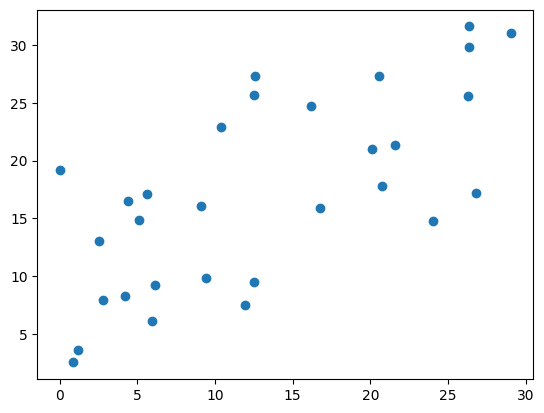

In [14]:
np.random.seed(1)
x,y = gen_linear_samples(30, sz=30, a=0.6, s=10, b=10)
plt.scatter(x,y)

<div class="alert alert-info">
 <b>HINT:</b> Add an aditional column with the value equal to 1 to define  <i>features</i>; if you want to use the predictor function using matrices.
</div>

## Solution

In [15]:
bias = np.ones(shape=(len(x),1))
Features = np.append(bias, x, axis=1)

In [16]:
Features

array([[1.00000000e+00, 1.25106601e+01],
       [1.00000000e+00, 2.16097348e+01],
       [1.00000000e+00, 3.43124452e-03],
       [1.00000000e+00, 9.06997718e+00],
       [1.00000000e+00, 4.40267672e+00],
       [1.00000000e+00, 2.77015784e+00],
       [1.00000000e+00, 5.58780634e+00],
       [1.00000000e+00, 1.03668218e+01],
       [1.00000000e+00, 1.19030242e+01],
       [1.00000000e+00, 1.61645020e+01],
       [1.00000000e+00, 1.25758354e+01],
       [1.00000000e+00, 2.05565850e+01],
       [1.00000000e+00, 6.13356749e+00],
       [1.00000000e+00, 2.63435231e+01],
       [1.00000000e+00, 8.21627796e-01],
       [1.00000000e+00, 2.01140253e+01],
       [1.00000000e+00, 1.25191441e+01],
       [1.00000000e+00, 1.67606949e+01],
       [1.00000000e+00, 4.21160816e+00],
       [1.00000000e+00, 5.94304467e+00],
       [1.00000000e+00, 2.40223371e+01],
       [1.00000000e+00, 2.90478473e+01],
       [1.00000000e+00, 9.40272534e+00],
       [1.00000000e+00, 2.07696785e+01],
       [1.000000

Let us use the **Least Square** cost function.

In [17]:
def predictor(Features, Weights):
    return Features @ Weights

# Least Squared
def cost_function(Features, Y, Weights):
    Ypred = predictor(Features, Weights)
    sq_error = (Y - Ypred)**2
    return sq_error.sum()/2

Let us define the weights $w=\left[\begin{matrix}10\\0.3\end{matrix} \right]$ and compute the cost function.

In [18]:
w = np.array([[10],[0.3]])
cost_function(Features, y, w)

np.float64(815.7678743192417)

Now, let us change the weights to verify how the value of cost function changes.

In [19]:
w = np.array([[10],[0.4]])
cost_function(Features, y, w)

np.float64(645.1138966100725)

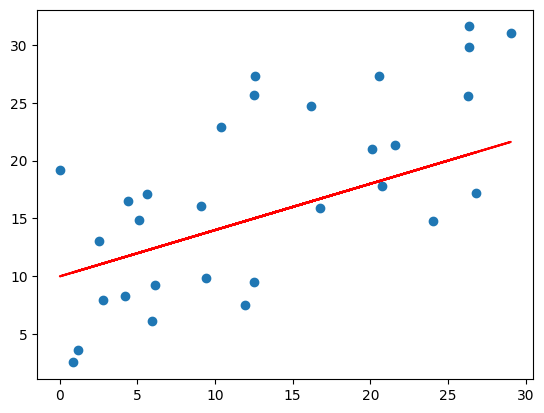

In [20]:
# Plotting the regression line
plt.scatter(x,y)
plt.plot(x, w[0]+w[1]*x,'r')

Now, let us do the same with the **Mean Square Error** cost function

In [ ]:
def predictor(Features, Weights):
    return Features @ Weights

# Mean Square Error (MSE)
def cost_function(Features, Y, Weights):
    n = len(Y)
    Ypred = predictor(Features, Weights)
    sq_error = (Y - Ypred)**2
    return 1/(2*n) * sq_error.sum()

In [22]:
# Set weight 
w = np.array([[10.0],[0.3]])
# Compute the cost fuction
cost_function(Features, y, w)

np.float64(27.19226247730806)

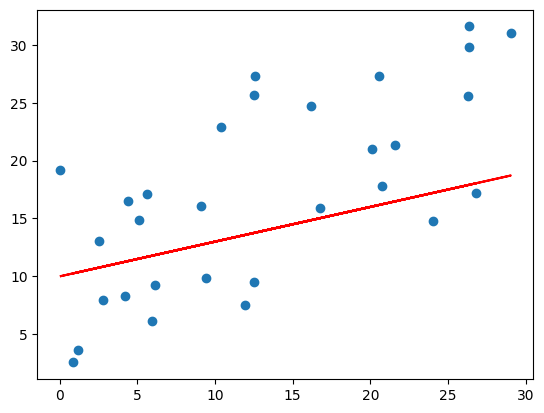

In [23]:
plt.scatter(x,y)
plt.plot(x, w[0]+w[1]*x,'r')

In [24]:
from ipywidgets import interact

def change_weights(X,Y):
    bias = np.ones(shape=(len(X),1))
    Features = np.append(bias, x, axis=1)
    def change(w0,w1):
        plt.scatter(X,Y)
        plt.plot(X, w0 + w1*X,'r')
        w = np.array([[w0],[w1]])
        cost = cost_function(Features,Y,w)
        plt.title("Cost fuction: {}".format(cost))
        plt.show()
    interact(change, w0=(0,30,0.1), w1=(-2,2,0.1))

change_weights(x,y)

interactive(children=(FloatSlider(value=15.0, description='w0', max=30.0), FloatSlider(value=0.0, description=…

<div class="alert alert-warning">
  <b>INFO:</b> <tt>ipwidgets</tt> only works with normal jupyter, it does not work with colab.research.google.com or jupyterlab
</div>

# Gradient descent

So far, we use a line with given parameters (weights) to represent a regression model. When we know what a cost function is we can look at methods for automatic determining values of the model weigthts. This can be accomplished via minimizig a value of cost function. So ...

The objective is to minimize a cost function
$$
\underset{\overrightarrow{\theta}}{\text{min}}\ J(\overrightarrow{\theta})
$$

In our case

$$
\underset{\theta_0,\theta_1}{\text{min}}\ J(\theta_0,\theta_1)
$$


**Gradient descent** is a method for minimizing a function (finding a local minimum). It iteratively changes the values of the parameters in a direction that helps to reach the minimum.

$$
\theta := \theta - \alpha\nabla J(\theta)
$$

$$
\theta_i := \theta_i - \alpha\frac{\partial}{\partial\theta_i}J(\theta)
$$ 

for $0\le i <$ # of parameters, while $\alpha$ is a learning rate.

The **learning rate** $\alpha$ determines the size of the steps taken at each iteration. If the learning rate is too high, the step could skip over the minimum. If the learning rate is to small, the algorithm will take more time to converge.  

## with Least Square cost function

The gradient descent with the Least Square is defined as follow:

$$
\theta := \theta - \alpha\nabla \frac{1}{2}\sum_{i=1}^n(y_i-f_\Theta(x_i))^2
$$

In the case of hypothesis $f_\theta(x) = \theta_0 + \theta_1 x$, each parameter changes as follow:

$$
\theta_0 := \theta_0 - \alpha\sum_{i=1}^n((\theta_0 + \theta_1x_i) - y_i)
$$

$$
\theta_1 := \theta_1 - \alpha\sum_{i=1}^n x_i((\theta_0 + \theta_1x_i) - y_i)
$$ 


In [25]:
# Gradient using Least Square
def gradient(X, Y, Weights):
    """
    X: x coordinates of the input data points (n x 1)
    Y: y coordinates of the input data points (true values) (n x 1)
    Weights: vector of weights (2 x 1)
    """
    # Gradient for theta_0
    grad0 = (Weights[0]+Weights[1]*X) - Y
    # Gradient for theta_1
    grad1 = X @ ((Weights[0]+Weights[1]*X) - Y).T
    return np.array([[grad0.sum()],[grad1.sum()]])

In [26]:
w = np.array([[10],[0.4]])
grad = gradient(Features, y, w)
grad

array([[  -262.14515139],
       [-29105.1556859 ]])

In [27]:
learning_rate = 0.00001
nw = w - learning_rate * grad
nw

array([[10.00262145],
       [ 0.69105156]])

Using the same points (`x`, `y`) as before, and with one step, we can observe the following results: 

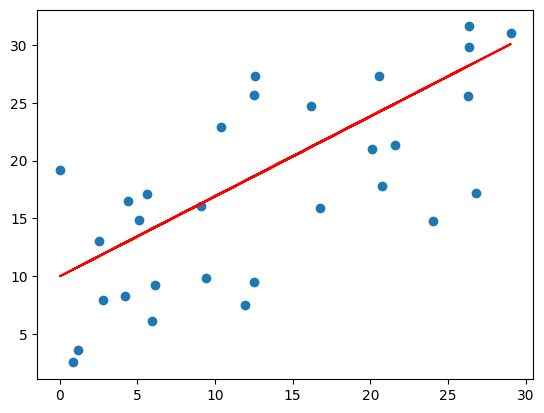

In [33]:
plt.scatter(x,y)
plt.plot(x, nw[0]+nw[1]*x,'r')
old_est = nw[0]+nw[1]*x

Now, we add an iteration loop and have:

In [34]:
w = np.array([[10],[0.4]])
for i in range(1000):
    grad = gradient(Features, y, w)
    w = w - 0.000001*grad

In [35]:
w

array([[10.18082062],
       [ 0.57367742]])

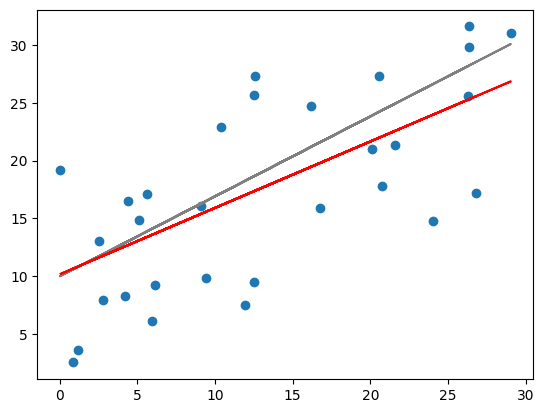

In [36]:
plt.scatter(x,y)
plt.plot(x, old_est, color="gray", label="previous line")
plt.plot(x, w[0]+w[1]*x,'r', label="new line")

Similarly, we define the gradient descent using Mean Square Error cost function (below).

## with Mean Square Error (MSE) cost function

$$
\theta := \theta - \alpha\nabla \frac{1}{2n}\sum_{i=1}^n(y_i-f_\Theta(x_i))^2
$$

In the case of $f_\theta(x) = \theta_0 + \theta_1 x$, we have

$$
\theta_0 := \theta_0 - \alpha\frac{1}{n}\sum_{i=1}^n((\theta_0 + \theta_1x_i) - y_i)
$$

$$
\theta_1 := \theta_1 - \alpha\frac{1}{n}\sum_{i=1}^n x_i((\theta_0 + \theta_1x_i) - y_i)
$$ 

In [37]:
# Gradient using Mean Square Error
def gradient(X, Y, Weights):
    m = len(Y)
    grad0 = (Weights[0]+Weights[1]*X) - Y
    grad1 = X @ ((Weights[0]+Weights[1]*X) - Y).T
    grad0 = (1/m)*grad0.sum()
    grad1 = (1/m)*grad1.sum()
    return np.array([[grad0],[grad1]])

In [38]:
w = np.array([[10],[0.4]])
grad = gradient(Features, y, w)
grad

array([[  -8.73817171],
       [-970.1718562 ]])

In [40]:
learning_rate = 0.00001
nw = w - learning_rate * grad
nw

array([[10.00008738],
       [ 0.40970172]])

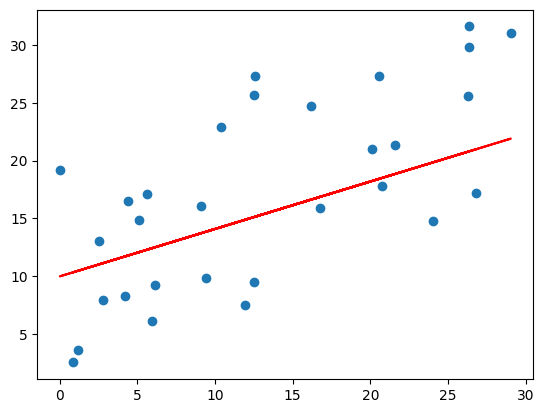

In [41]:
plt.scatter(x,y)
plt.plot(x, nw[0]+nw[1]*x,'r')

And with the loop (iteration) we obtain

In [42]:
w = np.array([[10],[0.4]])
for i in range(10000):
    grad = gradient(Features, y, w)
    w = w - 0.0001*grad

In [43]:
w

array([[14.10514083],
       [ 0.25210776]])

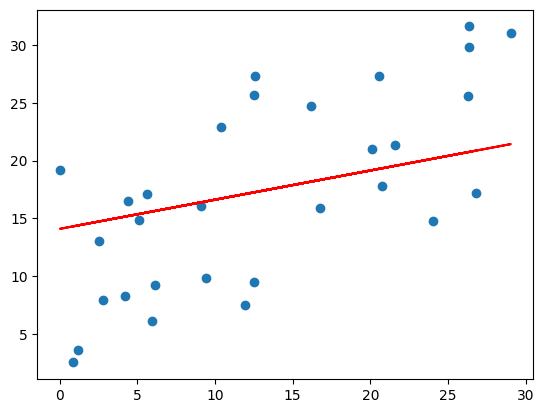

In [44]:
plt.scatter(x,y)
plt.plot(x, w[0]+w[1]*x,'r')

# Putting everything together

Now, we put all these things together. Additionally, we update the previously defined functions to use matrix operations,
and define a proper training function. 

As a result, we obtain the following code:

In [45]:
def predict(Features, Weights):
    return Features @ Weights

def cost_function(X, Y, Weights):
    n = len(Y)
    Ypred = predict(X, Weights)
    sq_error = (Y - Ypred)**2
    return 1/(2*n) * sq_error.sum()

def update_weights(X, Y, Weights, learning_rate):
    n = len(Y)
    Ypred = predict(X, Weights)
    error = Ypred - Y
    grad = (error.T @ X).T
    newWeights = Weights - learning_rate *(1/n) * grad
    return newWeights
    
def train(X, Y, learning_rate, n_iterations):
    # Step to log the intermediant result
    step = n_iterations/10
    
    # History of cost function progress
    mse_history = []
    
    # History on weights change
    w_history = []
    
    # Adding bias term (w0)
    bias = np.ones(shape=(len(X),1))
    Features = np.append(bias, X, axis=1)
    
    # Initial setup of Weights to 1
#     Weights = 0.2*np.ones((Features.shape[1],1))
    Weights = np.random.ranf([Features.shape[1],1])
    
    print("iter\t Cost \t\t Weights")
    for i in range(n_iterations):
        Weights = update_weights(Features, Y, Weights, learning_rate)
        cost = cost_function(Features, Y, Weights)
        mse_history.append(cost)
        w_history.append(Weights.flatten())
        if i%step==0:
            print("{}\t{:0.8}\t{}".format(i,cost,Weights.T))
    return Weights, mse_history, w_history

Let us test the code with a generated set of points.

In [46]:
np.random.seed(1)
x,y = gen_linear_samples(100, sz=30, a=-0.5, s=10, b=10)

# w: resulting parameters after train
# h: cost function history
# w_h: parameters history
w, h, w_h = train(x,y,0.0065, 10000)

iter	 Cost 		 Weights
0	75.724761	[[ 0.90691518 -0.61871937]]
1000	20.32349	[[ 8.37707339 -0.43848438]]
2000	19.998867	[[ 9.67988273 -0.50392113]]
3000	19.988919	[[ 9.90794467 -0.51537609]]
4000	19.988614	[[ 9.94786781 -0.51738133]]
5000	19.988605	[[ 9.95485652 -0.51773235]]
6000	19.988605	[[ 9.95607992 -0.5177938 ]]
7000	19.988605	[[ 9.95629408 -0.51780456]]
8000	19.988605	[[ 9.95633157 -0.51780644]]
9000	19.988605	[[ 9.95633813 -0.51780677]]


In [47]:
w

array([[ 9.95633928],
       [-0.51780683]])

Let us plot the cost function values over interations. Observe how the values decrease with each iteration.

Text(0, 0.5, 'training error')

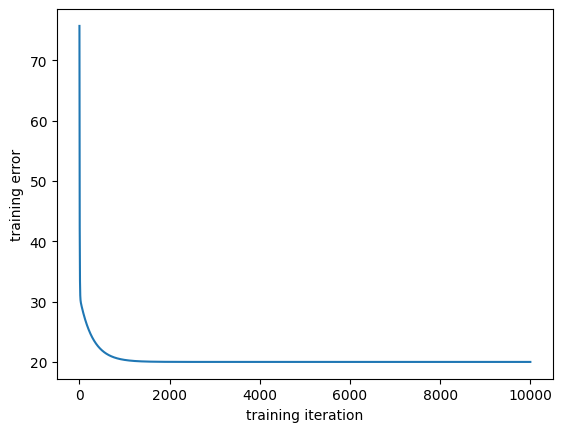

In [49]:
plt.plot(h)
plt.xlabel("training iteration")
plt.ylabel("training error")

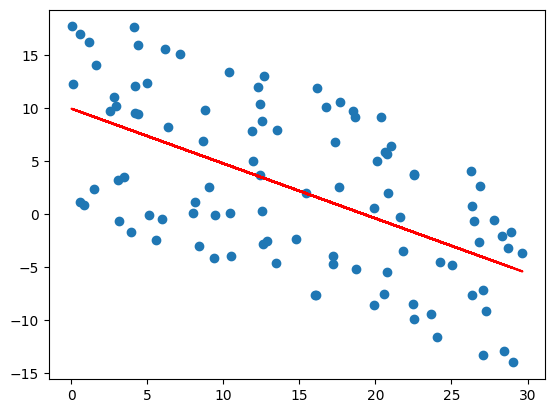

In [50]:
plt.scatter(x,y)
plt.plot(x,w[0]+w[1]*x,'r')

## Countour plot of the cost function 

Both cost functions ($J(\theta)$) Least Square and Mean Square Error define a convex surface that can be represented using a countour plot. If we also plot changes in the values of parameters, we can observe how the parameters 'move' towards the function minimum.

In [54]:
bias = np.ones(shape=(len(x),1))
Features = np.append(bias, x, axis=1)
wh = np.array(w_h).T

z = []
w0 = np.arange(-1,0.2,0.1)
w1 = np.arange(0,15,0.1)

for i in w1:
    tmp = []
    for j in w0:
        W = np.array([[i],[j]])
        cost = cost_function(Features, y, W)
        tmp.append(cost)
    z.append(tmp)

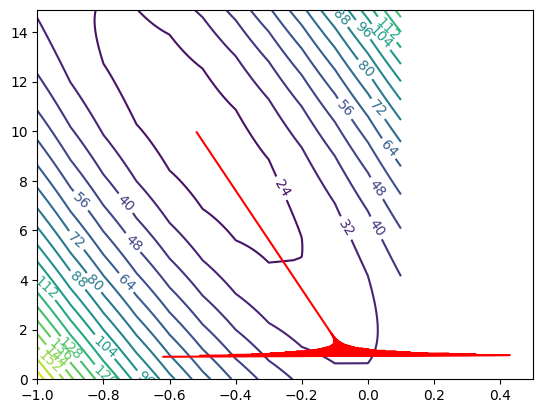

In [55]:
fig, ax = plt.subplots()
CS = ax.contour(w0, w1, z, levels=20)
ax.clabel(CS, inline=1, fontsize=10)
plt.plot(wh[1],wh[0],'r')

# Case Study and Exercise

We have used a generated dataset to test our code. Now, let us try to use real data. The Advertising Data Set (data/Advertising.csv) consists of sales data for a single product across 200 different markets, along with advertising budgets for the product in each of those markets for three different media: TV, radio, and newspaper.

TV, radio, and newspaper are the independent variables. The dependent variable is sales. All values are in 1000s.

To manipulate the date, we use **pandas** library.

In [56]:
import pandas as pd

In [57]:
data = pd.read_csv('data/Advertising.csv')
# data = pd.read_csv('http://www-bcf.usc.edu/~gareth/ISL/Advertising.csv', index_col=0)

A brief overview of the data:

In [58]:
data.head()

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [59]:
data.describe()

,Unnamed: 0,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


To learn how the data is distributed, we can plot the relation between each medium's budget against sales.

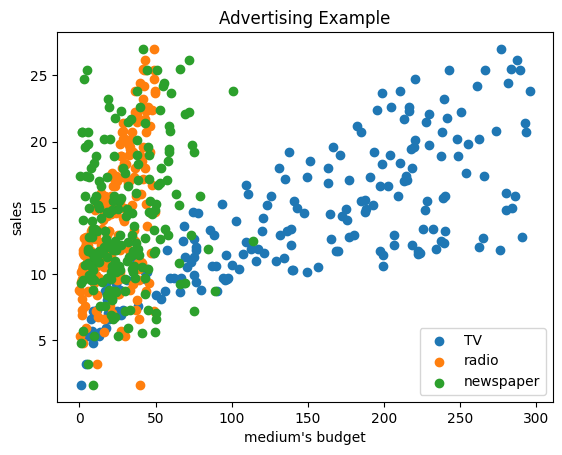

In [64]:
plt.scatter(data['TV'], data['sales'],label='TV')
plt.scatter(data['radio'], data['sales'],label='radio')
plt.scatter(data['newspaper'], data['sales'],label='newspaper')
plt.ylabel("sales")
plt.xlabel("medium's budget")
plt.title("Advertising Example")
plt.legend()

Now we try to predict the sales that can be obtained if we invest a certain amount of money in radio. To see how the amount of training points affect the prediction, we will use only a portion of the data points.

In [65]:
train_data = data.sample(150).copy()
X = train_data.loc[:,['radio']].values
Y = train_data['sales'].values.reshape(len(X),1)

In [66]:
w,h, w_h = train(X,Y,0.002, 20000)

iter	 Cost 		 Weights
0	27.621528	[[0.71446162 0.32046778]]
2000	10.81664	[[6.57777132 0.27803489]]
4000	9.7838828	[[8.51495454 0.21731784]]
6000	9.6709787	[[9.15546541 0.19724233]]
8000	9.6586357	[[9.36724412 0.19060456]]
10000	9.6572863	[[9.43726669 0.18840985]]
12000	9.6571388	[[9.46041898 0.18768418]]
14000	9.6571227	[[9.46807406 0.18744425]]
16000	9.6571209	[[9.47060514 0.18736492]]
18000	9.6571207	[[9.47144201 0.18733869]]


In [67]:
w

array([[9.47171864],
       [0.18733002]])

Text(0, 0.5, 'training error')

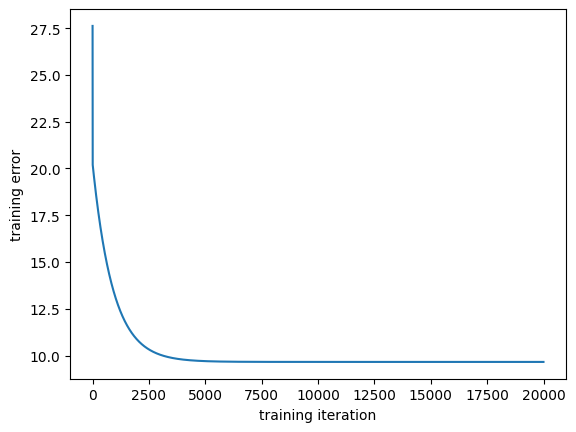

In [69]:
plt.plot(h)
plt.xlabel("training iteration")
plt.ylabel("training error")

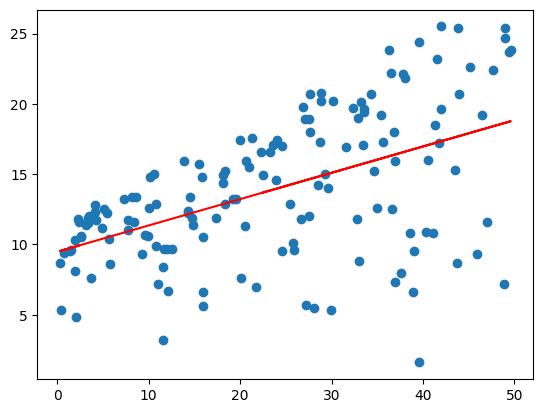

In [70]:
plt.scatter(X,Y)
plt.plot(X,w[0]+w[1]*X,'r')

<div class="alert alert-success">
<h2>Exercise</h2>

✏️ Change the learning rate and the number of iterations to check how the model is affected. Create a model to predict the sales when only the TV budget or only the newspaper budget is used.
</div>

# Using scikit-learn

At this point, we are familiar with linear regression and gradien descent, and how they work and are implemented. 

However, in a production we can use generalized and optimized libraries that contain functions that implement a variety of machine learning functions. An example of such a library is [scikit-learn](https://scikit-learn.org/).

In [73]:
from sklearn import linear_model

Here, we are interested in `LinearRegresion`.

In [74]:
lreg = linear_model.LinearRegression()

As before, we work with a subset of the data points.

In [75]:
train_data = data.sample(150).copy()
train_x = train_data.loc[:,['radio']].values
train_y = train_data['sales'].values.reshape(len(train_x),1)

To train the model, we use the method `fit` from the linear regression object.

In [76]:
lreg.fit(train_x,train_y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Once the training process is finished, the attribute `intercept_` contains the parameter $\theta_0$ and the parameter `coef_` contains the rest of the parameters ($\theta_1, \theta_2, ,,,$), depending of the number of parameters we have in our model. In the case of our data, we only have one, $\theta_1$.

In [77]:
wsk = lreg.intercept_,lreg.coef_[0]
wsk

(array([9.03853978]), array([0.21490979]))

Let us visually compare the results from our implementation (green) with the result from scikit-learn (red). 
We obtain: 

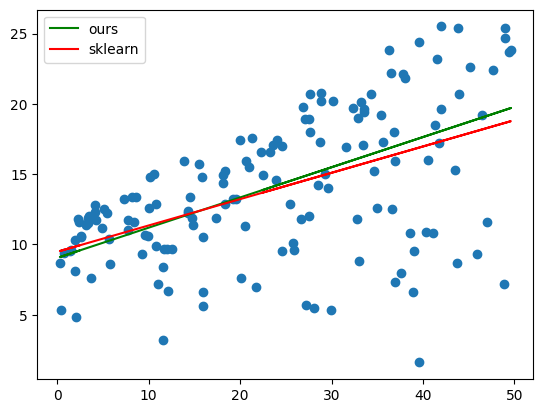

In [79]:
plt.scatter(X,Y)
plt.plot(X,wsk[0]+wsk[1]*X,'g', label="ours")
plt.plot(X,w[0]+w[1]*X,'r', label="sklearn")
plt.legend()

<div class="alert alert-success">
<h2>Exercise</h2>

✏️ Use `scikit-learn` to implement a model for predicting the sales values based on the Advertising Data Set (data/Advertising.csv) when only the TV budget or only the newspaper budget is used. Compare the obtained results with the previous results.
</div>

# Recap


In this section, we show how a supervised learning method called regression works. We have presented the hypothesis (predictor), that models a linear regression, and illustrated how a cost function can be used to determine how well our model behaves. We have showm gradient descent as a technique to minimize the cost function, and how it can be applied to train the model. 
Finally, we use `scikit-learn` library to train our linear regression model.
